In [1]:
from pathlib import Path

import pandas as pd
from tqdm import tqdm

from utils import train_models_for_target

/home/aj/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Configuration

In [2]:
DATA_DIR = Path("output")
CSV_PATTERN = "dataset_winsize*.csv"

OUTPUT_DIR = Path("model_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42

TARGETS = {
    "label_time_to_event_seconds": "regression",
    "label_from_zone": "classification",
    "label_to_zone": "classification",
}

DROP_COLUMNS = [
    "fold_id",
    "label_is_auto",
    "label_time_to_event_seconds",
    "label_from_zone",
    "label_to_zone",
]

SUMMARY_FILENAME = "all_metrics_summary.csv"

In [3]:
############
# RUN ONCE #
############
# Main loop over datasets (takes abut 30 minutes)

# all_results = []

# csv_files = sorted(DATA_DIR.glob(CSV_PATTERN))

# if len(csv_files) == 0:
#     raise FileNotFoundError(
#         f"No files found matching {CSV_PATTERN} in {DATA_DIR.resolve()}"
#     )

# for csv_path in tqdm(csv_files):
#     dataset_name = csv_path.stem
#     print(f"\nReading {csv_path}")

#     df = pd.read_csv(csv_path)

#     for target_col, task_type in TARGETS.items():

#         metrics_df = train_models_for_target(
#             df=df,
#             dataset_name=dataset_name,
#             target_col=target_col,
#             task_type=task_type,
#             output_dir=OUTPUT_DIR,
#             random_state=RANDOM_STATE,
#             drop_columns=DROP_COLUMNS,
#         )

#         all_results.append(metrics_df)

# final_results = pd.concat(all_results, ignore_index=True)
# final_results.to_csv(OUTPUT_DIR / "all_metrics_summary.csv", index=False)

# print("\nFinal summary:")
# print(final_results)

In [4]:
metrics_df = pd.read_csv(OUTPUT_DIR / SUMMARY_FILENAME)
metrics_df.head()

,mae,median_absolute_error,mse,rmse,r2,dataset,target,task,model,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
0,157.196390,78.697248,48993.134294,221.343928,0.119525,dataset_winsize0.25h,label_time_to_event_seconds,regression,tree,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,150.967884,93.647092,45346.774349,212.947821,0.185055,dataset_winsize0.25h,label_time_to_event_seconds,regression,rf,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,dataset_winsize0.25h,label_from_zone,classification,tree,0.355401,0.161944,0.174300,0.148449,0.136624,0.501387,0.355401,0.383028
3,NaN,NaN,NaN,NaN,NaN,dataset_winsize0.25h,label_from_zone,classification,rf,0.536585,0.345244,0.299276,0.316474,0.290139,0.638963,0.536585,0.575050
4,NaN,NaN,NaN,NaN,NaN,dataset_winsize0.25h,label_to_zone,classification,tree,0.296167,0.153683,0.142584,0.140876,0.110448,0.463255,0.296167,0.345962


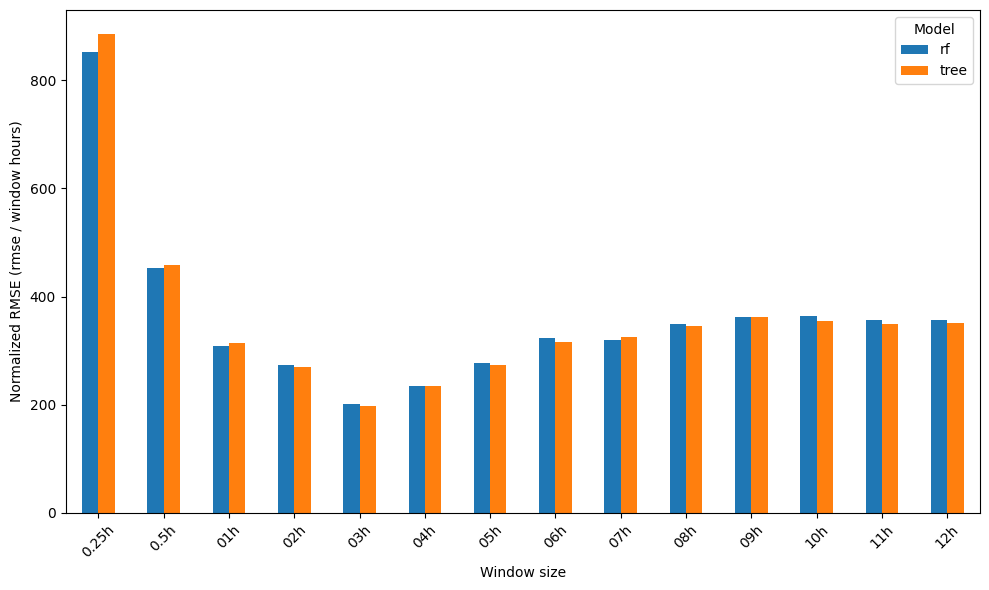

In [5]:
import matplotlib.pyplot as plt

reg_df = metrics_df[
    (metrics_df["task"] == "regression") & (metrics_df["model"].isin(["tree", "rf"]))
].copy()

reg_df["winsize"] = reg_df["dataset"].str.extract(r"winsize(.+)$", expand=False)
reg_df["winsize_hours"] = (
    reg_df["winsize"].str.replace("h", "", regex=False).astype(float)
)
reg_df["rmse_norm"] = reg_df["rmse"] / reg_df["winsize_hours"]

pivot = reg_df.sort_values("winsize_hours").pivot(
    index="winsize", columns="model", values="rmse_norm"
)

ax = pivot.plot(kind="bar", figsize=(10, 6))
ax.set_xlabel("Window size")
ax.set_ylabel("Normalized RMSE (rmse / window hours)")
# ax.set_title("Regression RMSE normalized by window size for tree vs rf")
ax.legend(title="Model")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

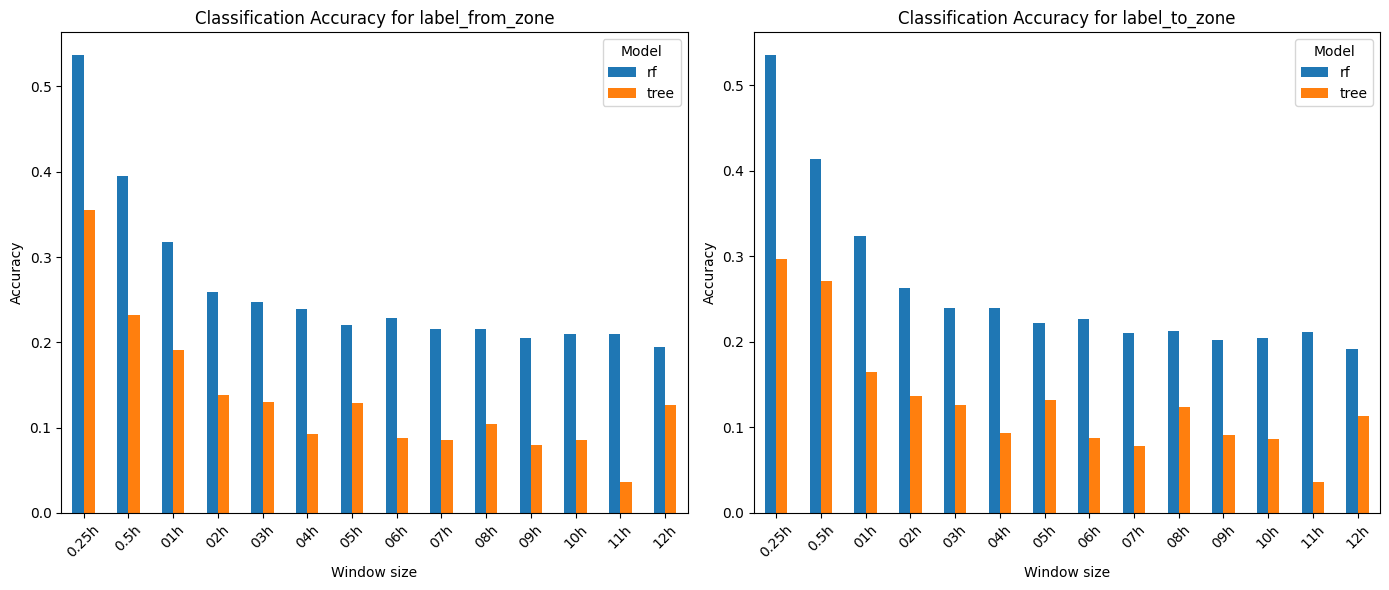

In [6]:
class_df = metrics_df[
    (metrics_df["task"] == "classification")
    & (metrics_df["target"].isin(["label_from_zone", "label_to_zone"]))
    & (metrics_df["model"].isin(["tree", "rf"]))
].copy()

class_df["winsize"] = class_df["dataset"].str.extract(r"winsize(.+)$", expand=False)
class_df["winsize_hours"] = (
    class_df["winsize"].str.replace("h", "", regex=False).astype(float)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, target in enumerate(["label_from_zone", "label_to_zone"]):
    target_data = class_df[class_df["target"] == target].sort_values("winsize_hours")
    pivot = target_data.pivot(index="winsize", columns="model", values="accuracy")

    ax = pivot.plot(kind="bar", ax=axes[idx])
    ax.set_xlabel("Window size")
    ax.set_ylabel("Accuracy")
    ax.set_title(f"Classification Accuracy for {target}")
    ax.legend(title="Model")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# train a classification model for time intervals
%run train_time_interval_classification.py

             dataset  n_train  n_test  accuracy  balanced_accuracy  interval_weighted_accuracy  balanced_interval_weighted_accuracy  n_[0,1)  n_[1,2)  n_[2,4)  n_[4,8)  n_[8,inf)  accuracy_[0,1)  accuracy_[1,2)  accuracy_[2,4)  accuracy_[4,8)  accuracy_[8,inf)
dataset_winsize0.25h     2295     574  1.000000           1.000000                    1.000000                             1.000000      574        0        0        0          0             1.0             NaN             NaN             NaN               NaN
 dataset_winsize0.5h     2875     719  1.000000           1.000000                    1.000000                             1.000000      719        0        0        0          0             1.0             NaN             NaN             NaN               NaN
  dataset_winsize01h     3630     908  1.000000           1.000000                    1.000000                             1.000000      908        0        0        0          0             1.0             NaN       